# Target stability — `total_points` (Y) across the season
_Read-only: how the target's distribution moves across three season blocks, per position — whether the season can be treated as one pool. Verdicts are operational heuristics, not gates._

**Sections:** (a) distribution per GW block · (b) stability verdict & pooling guidance

---

## Setup
> Whole season, `minutes > 0`, three contiguous GW blocks (early / mid / late, dynamic thirds).

**DGW confound.** A DGW row sums two fixtures into one `total_points`, inflating the upper tail, and DGW rounds cluster late — so apparent late-season drift may be fixture-doubling. These distributions pool SGW and DGW and flag it; per-fixture normalisation is the `fixture/` layer's job.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.block_distributions import (
    compute_signal_block_distributions,
)
from research.kernels.diagnostic.stability import (
    assess_distribution_stability,
    resolve_pooling_strategy,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that GW-6 cut in the older EDA-1
# record was a predictive-evaluation choice, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

# Analytical population: PARTICIPATION filter, not a performance gate.
# Available players who actually featured -> minutes > 0. `minutes` can be NULL
# for some rows; minutes > 0 naturally excludes NULLs (NULL comparisons are
# False). The 60-minute performance boundary is NOT imposed here -- that
# question is deferred to the exposure/ layer.
mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()

POSITIONS = ["GK", "DEF", "MID", "FWD"]

# Temporal unit: split the WHOLE completed season into three contiguous,
# (near-)equal GW blocks -- early / mid / late -- computed dynamically from the
# GW range so this notebook adapts to whatever the season's data_cutoff_gw is.
def _make_thirds(gw_min, gw_max):
    span = gw_max - gw_min + 1
    cut1 = gw_min + span // 3            # end of "early" (inclusive)
    cut2 = gw_min + (2 * span) // 3      # end of "mid"   (inclusive)
    return {
        "early": (gw_min, cut1),
        "mid":   (cut1 + 1, cut2),
        "late":  (cut2 + 1, gw_max),
    }

GW_BLOCKS = _make_thirds(STUDY_GW_MIN, STUDY_GW_MAX)
BLOCK_ORDER = ["early", "mid", "late"]

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0 (participation, not a performance gate), n = {len(df):,} player-gameweeks")
for pos in POSITIONS:
    print(f"  {pos}: {len(df[df.position == pos]):>6,}")
print("\nGW blocks (thirds of the completed season, inclusive bounds):")
for name in BLOCK_ORDER:
    lo, hi = GW_BLOCKS[name]
    print(f"  {name:<6} GW {lo:>2} - {hi:<2}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0 (participation, not a performance gate), n = 11,361 player-gameweeks
  GK:    757
  DEF:  3,904
  MID:  5,288
  FWD:  1,412

GW blocks (thirds of the completed season, inclusive bounds):
  early  GW  1 - 13
  mid    GW 14 - 26
  late   GW 27 - 38


## (a) `total_points` distribution per GW block, by position
> Does scoring drift across the season, and is a position more or less volatile at different points in it?

For each (position, block), the median / IQR / p90 / p99 of `total_points` via `compute_signal_block_distributions`; the plot pairs the IQR band with the p90/p99 tail because the median is flat at 2 everywhere — what moves is the spread and the haul ceiling, not the centre. `n` per cell is shown so thin blocks are visible.

In [2]:
# Y distribution per (position, block). total_points is just a column -> pass
# it as the single "signal". The kernel returns NaN for blocks with n < 10.
y_blocks = compute_signal_block_distributions(
    df, ["total_points"], POSITIONS, gw_column="gw", gw_blocks=GW_BLOCKS,
)

# Order blocks early -> mid -> late and positions GK..FWD for readability.
y_blocks["block"] = pd.Categorical(y_blocks["block"], categories=BLOCK_ORDER, ordered=True)
y_blocks["position"] = pd.Categorical(y_blocks["position"], categories=POSITIONS, ordered=True)
y_blocks = y_blocks.sort_values(["position", "block"]).reset_index(drop=True)
display(y_blocks[["position", "block", "min_gw", "max_gw", "n", "median", "q1", "q3", "iqr", "p90", "p99"]])

,position,block,min_gw,max_gw,n,median,q1,q3,iqr,p90,p99
0,GK,early,1,13,262,2.000,2.000,6.000,4.000,7.000,10.000
1,GK,mid,14,26,263,2.000,1.000,4.500,3.500,7.000,11.760
2,GK,late,27,38,232,2.000,2.000,6.000,4.000,7.000,11.000
3,DEF,early,1,13,1345,2.000,1.000,4.000,3.000,8.000,14.000
4,DEF,mid,14,26,1374,2.000,1.000,5.000,4.000,8.000,13.270
5,DEF,late,27,38,1185,2.000,1.000,5.000,4.000,7.600,15.000
6,MID,early,1,13,1923,2.000,1.000,3.000,2.000,7.000,13.000
7,MID,mid,14,26,1772,2.000,1.000,4.000,3.000,7.000,14.000
8,MID,late,27,38,1593,2.000,1.000,4.000,3.000,7.000,13.000
9,FWD,early,1,13,447,2.000,1.000,2.000,1.000,8.000,13.000


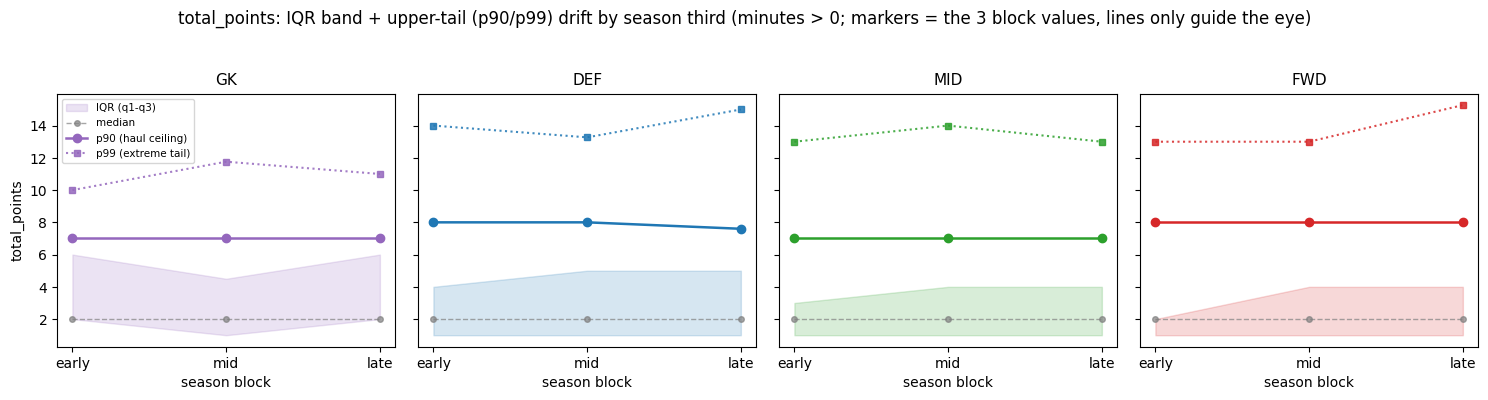

In [3]:
# Per-position view across blocks, redesigned to show what actually moves.
# The median is flat at 2 for every (position, block), so a median line
# carries no information here; the real drift is in (a) the IQR band and
# (b) the upper tail (p90/p99) -- the haul ceiling, where total_points
# variation actually lives. Median is kept only as a faint grey reference.
# sharey puts all positions on one scale for cross-position comparison.
colours = {"GK": "#9467bd", "DEF": "#1f77b4", "MID": "#2ca02c", "FWD": "#d62728"}
x = np.arange(len(BLOCK_ORDER))
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True)
for ax, pos in zip(axes, POSITIONS):
    sub = y_blocks[y_blocks["position"] == pos].set_index("block").reindex(BLOCK_ORDER)
    q1 = sub["q1"].to_numpy(dtype=float)
    q3 = sub["q3"].to_numpy(dtype=float)
    med = sub["median"].to_numpy(dtype=float)
    p90 = sub["p90"].to_numpy(dtype=float)
    p99 = sub["p99"].to_numpy(dtype=float)
    c = colours[pos]
    ax.fill_between(x, q1, q3, color=c, alpha=0.18, label="IQR (q1-q3)")
    ax.plot(x, med, "--o", color="grey", lw=1, ms=4, alpha=0.7, label="median")
    ax.plot(x, p90, "-o", color=c, lw=1.8, ms=6, label="p90 (haul ceiling)")
    ax.plot(x, p99, ":s", color=c, lw=1.5, ms=5, alpha=0.85, label="p99 (extreme tail)")
    ax.set_xticks(x)
    ax.set_xticklabels(BLOCK_ORDER)
    ax.set_title(pos, fontsize=11)
    ax.set_xlabel("season block")
axes[0].set_ylabel("total_points")
axes[0].legend(fontsize=7.5, loc="upper left")
fig.suptitle("total_points: IQR band + upper-tail (p90/p99) drift by season third "
             "(minutes > 0; markers = the 3 block values, lines only guide the eye)", y=1.04)
plt.tight_layout()
plt.show()

## (b) Stability verdict and pooling guidance, per position
> Can we treat the whole season as one pool for the target, or must we split — and does it depend on position?

Each position's three-block stats feed `assess_distribution_stability` (`{stable, moderate_shift, unstable}` from the largest normalised median shift), mapped to a pooling decision by `resolve_pooling_strategy`. The thresholds (`STABLE_THRESHOLD = 0.5`, `UNSTABLE_THRESHOLD = 1.5`) are operational heuristics, not a gate — nothing downstream is blocked by an `unstable` here; the DGW confound can manufacture a late shift.

In [4]:
# Per-position stability verdict + pooling guidance for Y. Heuristic thresholds
# (STABLE=0.5, UNSTABLE=1.5 on normalised median shift) -- analytical guidance,
# NOT a gate.
rows = []
for pos in POSITIONS:
    block_stats = y_blocks[y_blocks["position"] == pos]
    verdict = assess_distribution_stability(block_stats)
    pooling = resolve_pooling_strategy(verdict)
    rows.append({
        "position": pos,
        "n_blocks_valid": int(block_stats["median"].notna().sum()),
        "stability_verdict": verdict,
        "pooling_guidance": pooling,
    })
target_stability = pd.DataFrame(rows)
display(target_stability)

,position,n_blocks_valid,stability_verdict,pooling_guidance
0,GK,3,stable,pool_confirmed
1,DEF,3,stable,pool_confirmed
2,MID,3,stable,pool_confirmed
3,FWD,3,stable,pool_confirmed
